# Computer Vision Assignments: Sessions 1 & 2

This notebook contains tasks and assignments based on Sessions 1 and 2. You are required to implement the functions and complete the exercises as described. Use OpenCV and other necessary libraries like NumPy and Matplotlib.

**Instructions:**
- Complete each task in the provided code cells.
- Test your implementations with sample images (e.g., download test images [here](https://sipi.usc.edu/database/database.php?volume=misc) or [here](https://www.hlevkin.com/hlevkin/06testimages.htm) or use your own test images).
- Include comments in your code for clarity.
- Display results using cv2.imshow() or Matplotlib where appropriate.
- Submit the completed notebook along with any output images or explanations on [our google drive for the CV sessions](https://drive.google.com/drive/folders/1IjVhJmAXxNQTGT-ybJ-yc5smYtR5v8CO?usp=sharing) **upload your files in a new folder under your name**

## Session 1: Basic Image Operations (Reading, Resizing, Cropping, Rotating)

### Task 1: Read and Display an Image
Read an image from a file and display it in both BGR and grayscale formats. Handle errors if the image cannot be read.

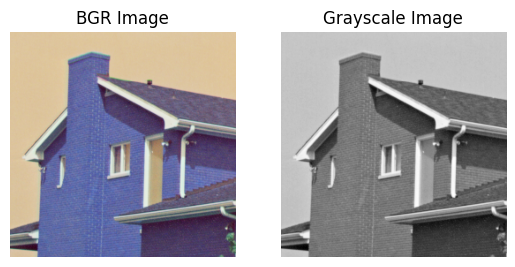

In [1]:
import cv2 as cv
import numpy as np
import sys
import matplotlib.pyplot as plt
%matplotlib inline

# Your code here
path = r'D:\AAST\SkyXperts\SkyXperts-Vision-Course\tasks\house.jpg'  # Replace with your image path

# Read in BGR
img_bgr = cv.imread(path)

# Read in Grayscale
img_gray = cv.imread(path, cv.IMREAD_GRAYSCALE)

# Display both using cv.imshow() or plt.imshow()
plt.subplot(1, 2, 1)
plt.imshow(img_bgr)
plt.title('BGR Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.show()

### Task 2: Resize Image with Aspect Ratio Preservation
Implement resizing while preserving aspect ratio. Downscale to 60% and upscale to 200%. Compare shapes and display originals vs resized.

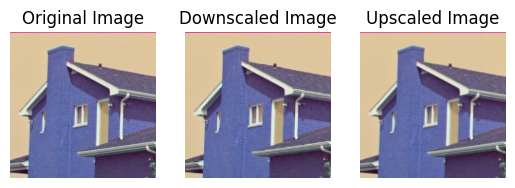

In [2]:
# Your code here
# Load image
img = cv.imread(path)

# Downscale to 60%
img_downscaled = cv.resize(img, None, fx=0.6, fy=0.6)

# Upscale to 200%
img_upscaled = cv.resize(img, None, fx=2.0, fy=2.0)

# Display all three
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_downscaled)
plt.title('Downscaled Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_upscaled)
plt.title('Upscaled Image')
plt.axis('off')

plt.show()

### Task 3: Resize Without Preserving Aspect Ratio
Resize only width to 100 pixels, only height to 200 pixels, and both to (200, 200). Display and discuss distortions.

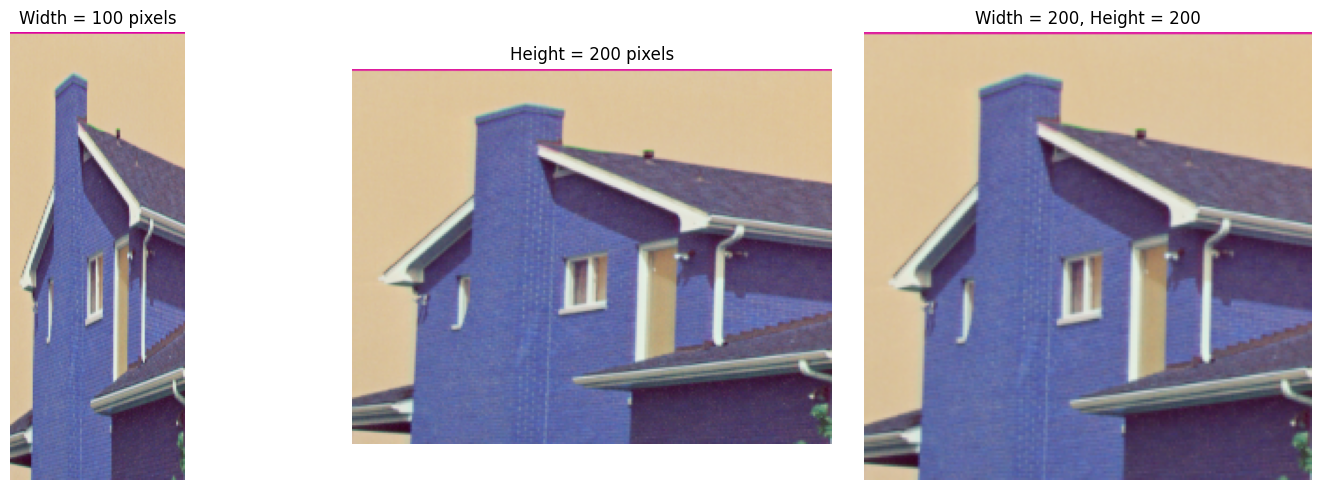

In [ ]:
# Load the image
img = cv.imread(path)

height, width = img.shape[:2]

width_only = cv.resize(img, (100, height))
height_only = cv.resize(img, (width, 200))
both = cv.resize(img, (200, 200))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(width_only)
plt.title("Width = 100 pixels")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(height_only)
plt.title("Height = 200 pixels")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(both)
plt.title("Width = 200, Height = 200")
plt.axis("off")

plt.tight_layout()
plt.show()

### Task 4: Resize Using Scale Factors (fx, fy)
Scale up by 1.2 in both directions and down by 0.6. Use different interpolations (INTER_LINEAR, INTER_NEAREST) and compare quality.

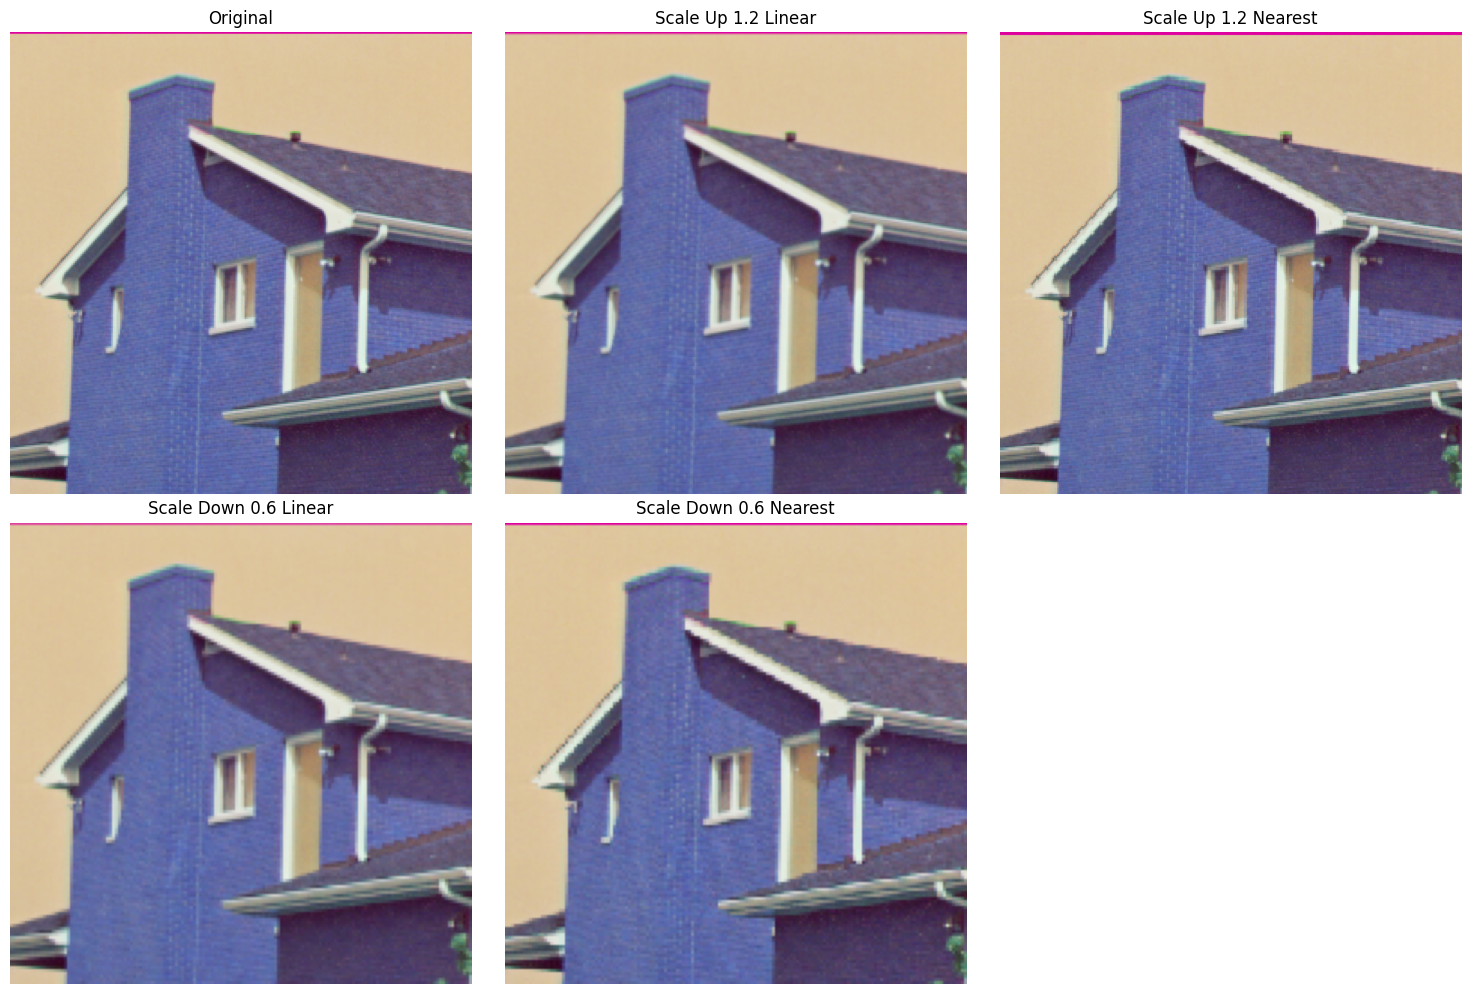

In [ ]:
# Your code here
# Experiment with interpolations


scaled_up_linear= cv.resize(img, None, fx=1.2, fy=1.2, interpolation=cv.INTER_LINEAR)
scaled_up_nearest= cv.resize(img, None, fx=1.2, fy=1.2, interpolation=cv.INTER_NEAREST)
scaled_down_linear= cv.resize(img, None, fx=0.6, fy=0.6, interpolation=cv.INTER_LINEAR)
scaled_down_nearest= cv.resize(img, None, fx=0.6, fy=0.6, interpolation=cv.INTER_NEAREST)

images = [
    ("Original", img),
    ("Scale Up 1.2 Linear", scaled_up_linear),
    ("Scale Up 1.2 Nearest", scaled_up_nearest),
    ("Scale Down 0.6 Linear", scaled_down_linear),
    ("Scale Down 0.6 Nearest", scaled_down_nearest)
]

plt.figure(figsize=(15, 10))

for i, (title, image) in enumerate(images, 1):
    plt.subplot(2, 3, i)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Task 5: Cropping an Image
Crop a region (e.g., [20:200, 50:200]) from the image. Display original and cropped.

(np.float64(-0.5), np.float64(155.5), np.float64(199.5), np.float64(-0.5))

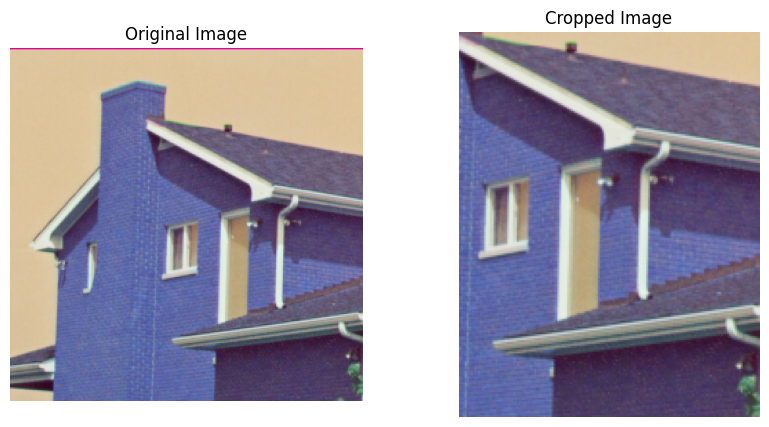

In [15]:
# Your code here
img = cv.imread(path)
img_cropped = img[50:250, 100:300] 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image") 
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(img_cropped)
plt.title("Cropped Image")
plt.axis("off")


### Task 6: Advanced Cropping - Patch Image into Blocks
Divide the image into 4 equal blocks (2x2 grid) by cropping. Display each block separately and then stitch them back using NumPy concatenation to verify.

In [ ]:
# Your code here
# Calculate midpoints for height and width
height,width=img.shape[:2]
mid_height =height // 2
mid_width =width // 2

# Crop into top-left, top-right, bottom-left, bottom-right
top_left= img[:mid_height, :mid_width]
top_right= img[:mid_height, mid_width:]
bottom_left= img[mid_height:, :mid_width]
bottom_right= img[mid_height:, mid_width:]

# Display each
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.imshow(top_left)
plt.title("Top Left")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(top_right)
plt.title("Top Right")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(bottom_left)
plt.title("Bottom Left")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(bottom_right)
plt.title("Bottom Right")
plt.axis("off")

plt.show()

# Stitch back (use np.hstack and np.vstack)
stitched = np.vstack([np.hstack([top_left, top_right]), np.hstack([bottom_left, bottom_right])])
plt.figure(figsize=(10, 10))
plt.imshow(stitched)
plt.title("Stitched Image")
plt.axis("off")
plt.show()

### Task 7: Rotating an Image
Rotate the image by 45°, 90°, and 180° using getRotationMatrix2D and warpAffine. Display all rotations.

In [ ]:
# Your code here
# Calculate center

# For each angle: get matrix, warp, display

### Task 8: Rotate with Scaling
Rotate by 45° and scale by 0.5 in **one** operation. Compare with separate resize and rotate.

In [ ]:
# Your code here

## Session 2: Image Acquisition, Formats, Color Spaces, Enhancement, and Filtering

### Task 9: Read Image in Different Color Spaces
Read an image in BGR, convert to RGB (for Matplotlib), HSV, LAB and Grayscale. Display all.

In [ ]:
# Your code here
# Use cv.cvtColor()

### Task 10: Image Sharpening
Apply cv2.blur() with a 5x5 kernel, then use cv2.filter2D() with sharpening kernels of varying strengths (e.g., [[0, -1, 0], [-1, 5, -1], [0, -1, 0]] and [[0, -2, 0], [-2, 9, -2], [0, -2, 0]]).
Compare between original and sharpened image after blurring.

In [ ]:
# Your code here
# Use cv2.blur
# Define sharpen kernel, use cv.filter2D()

### Task 11: Add Salt and Pepper Noise to Image
Implement a function to add salt and pepper noise to an image. Control noise density (e.g., 0.05).

In [ ]:
# Your code here
def add_salt_pepper_noise(image, density=0.05):
    # Implement using random pixels set to 0 or 255
    pass

# Apply to an image and display

### Task 12: Remove Salt and Pepper Noise Using Median Filter
Apply cv.medianBlur() to a noisy image. Experiment with kernel sizes (3,5,7) and compare results.

In [ ]:
# Your code here

### Task 13: Implement Adaptive Median Filter
Write a custom function for adaptive median filtering. It should dynamically increase window size until noise is removed or max size is reached. Apply to a noisy image and compare with standard median.

In [ ]:
# Your code here
def adaptive_median_filter(image, max_size=7):
    # Implement logic: for each pixel, start with small window, increase if needed
    pass

# Test on noisy image

### Task 14: Implement Bilateral Filter Function
Write a Python function to perform bilateral filtering on an image. Use Gaussian weights for both spatial and intensity. Parameters: diameter, sigma_color, sigma_space. Compare with cv.bilateralFilter().

In [ ]:
# Your code here
def custom_bilateral_filter(image, diameter, sigma_color, sigma_space):
    # Implement using nested loops or vectorized (efficiently)
    # For each pixel, compute weighted sum based on distance and intensity diff
    pass

# Apply to image, display, and compare with OpenCV's version

### [BONUS] Task 15: Comprehensive Camera Task 
Combine: Live camera feed -> grayscale -> add noise -> remove with median -> sharpen. Display all stages in separate windows.

In [ ]:
# To read video from camera example:

camera_id = 0
delay = 400
window_name = 'frame'

cap = cv.VideoCapture(camera_id)

if not cap.isOpened():
    sys.exit()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    cv.imshow(window_name, frame)
    if cv.waitKey(delay) & 0xFF == ord('q'):
        break

cap.release()
cv.destroyWindow(window_name)


# Your code here

### [BONUS]Task 16: Comprehensive Video Task
Similar to Task 18 but for a video file. Save the final processed video.

In [ ]:
# Your code here

### Task 17: Performance Comparison
Time the execution of standard median vs adaptive median on a large noisy image. Discuss when adaptive median filter is better.

In [ ]:
import time
# Your code here
# Use time.time() to measure
time.time()